In [16]:
%%HTML
<style>
body {
    --vscode-font-family : 'Nasalization';
}

.dataframe {
    font-family : 'Futura';
    # font-family : 'Century Gothic';
    border : 2px solid #252422;
    border-radius : 5px;
    overflow : hidden;
}

.dataframe tr th {
    text-align : center;
}

.dataframe td {
    paddign : 10px;
    text-align : left;
}

.dataframe tr:hover{
    background-color : #ef233c;
}

</style>

# 🛳️ Importation

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve, GridSearchCV, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# 🎯 Main

Il faut diviser un dataset en trois parties :
- Train
- Validation
- Test

Néanmoins l'ordre peux influcer les performances. <br>
On va donc passer les données dans plusieurs ordre. <br>
On parle de `Cross Validation`  <br>
Pour comparer les modèles, on va donc faire la `moyenne` puis choisir le plus performant  <br>

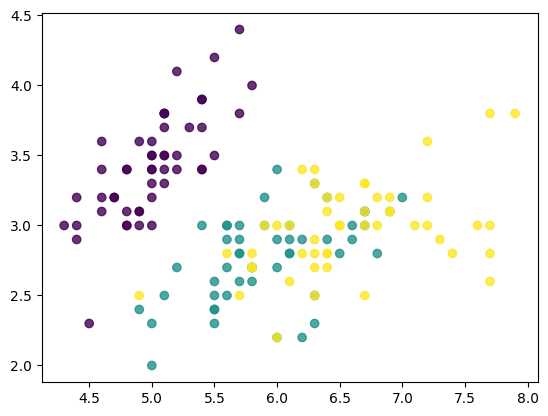

In [18]:
iris = load_iris()
X = iris.data
y = iris.target

plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)

## 📍 Sans validation

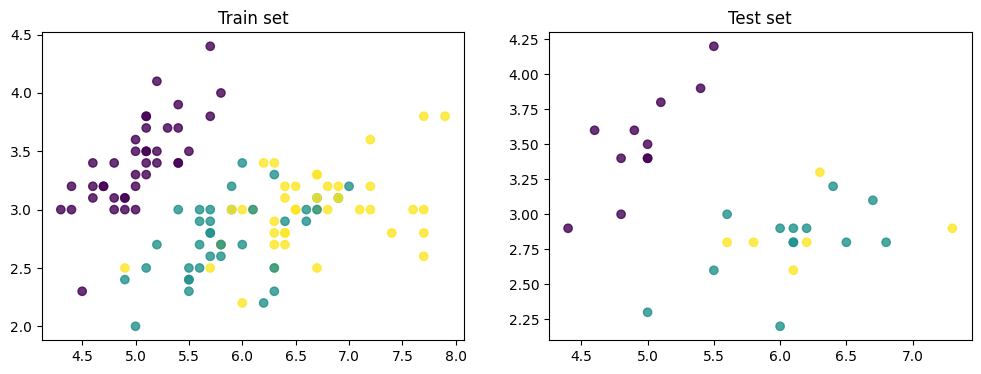

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.8)
plt.title('Train set')

plt.subplot(122)
plt.scatter(X_test[:, 0], X_test[:, 1],c=y_test, alpha=0.8)
plt.title('Test set')

plt.show()

## 📍 Avec validation

In [20]:
# On définit le modèle
modele = KNeighborsClassifier() # par défaut 1 centre

# On split notre dataset Train en 5 morceaux :
# 4 morceaux en train
# 1 en validation
# Cela va donc créer 5 découpes avec le val dans différentes positions

# [ [Val], [train], [train], [train], [train] ]
# [ [train], [Val], [train], [train], [train] ]
# [ [train], [train], [Val], [train], [train] ]
# [ [train], [train], [train], [Val], [train] ]
# [ [train], [train], [train], [train], [Val] ]

result_split = cross_val_score(modele, X_train, y_train, cv=5, scoring='accuracy')
result_split

array([0.95833333, 0.875     , 0.95833333, 1.        , 0.875     ])

In [21]:
# Pour chaque morceaux on affiche leur score
for i in range(len(result_split)) :
    print(f'Découpe {i+1} : {result_split[i]:.2f}')

Découpe 1 : 0.96
Découpe 2 : 0.88
Découpe 3 : 0.96
Découpe 4 : 1.00
Découpe 5 : 0.88


In [22]:
# On va retenir uniquement la moyenne
print(f'Pour K=1 voisin, le score moyen est de {result_split.mean():.2f}')

Pour K=1 voisin, le score moyen est de 0.93


## ⁉️ Il faut faire pareil pour autant de voisins voulu

In [31]:
modele = KNeighborsClassifier()
nb_voisins = np.arange(1, 50)

# La méthode validation curve nous donne :
#   - Le score pour le train (les 4 morceaux)
#   - Le score pour le validation (le morceau)

# n_neighbors : le nom de l'hyperparamètre dans KNeighborsClassifier (https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
# Il faut à côté rensigner les valeurs de ce hyperparamètre
# Dans notre cas : le nb_voisins

train_score, val_score = validation_curve(modele, X_train, y_train, param_name='n_neighbors', param_range=nb_voisins, cv=5)

# Affichage des résultats
# On retouve en colonne le score pour le validation dans chaque découpe (5 dans notre cas)
print('Score de chaque split pour chaque modèle :')
print('--------------------------------------------------')
for i in range(10) :
    print(f'Modèle avec K={i+1} : {val_score[i]}')

print('\n')

print('Score moyen de chaque modèle :')
print('--------------------------------------------------')

for i in range(10) :
    print(f'Modèle avec K={i+1} : {val_score[i].mean():.2f}')

# Même principe pour le train_score

Score de chaque split pour chaque modèle :
--------------------------------------------------
Modèle avec K=1 : [0.91666667 0.875      1.         1.         0.91666667]
Modèle avec K=2 : [0.91666667 0.83333333 1.         0.95833333 0.91666667]
Modèle avec K=3 : [0.91666667 0.83333333 1.         1.         0.875     ]
Modèle avec K=4 : [0.91666667 0.83333333 1.         1.         0.875     ]
Modèle avec K=5 : [0.95833333 0.875      0.95833333 1.         0.875     ]
Modèle avec K=6 : [0.95833333 0.875      1.         0.95833333 0.91666667]
Modèle avec K=7 : [0.95833333 0.95833333 1.         0.95833333 0.875     ]
Modèle avec K=8 : [0.95833333 0.95833333 1.         0.95833333 0.91666667]
Modèle avec K=9 : [0.95833333 0.95833333 1.         1.         0.875     ]
Modèle avec K=10 : [0.95833333 0.91666667 1.         0.95833333 0.91666667]


Score moyen de chaque modèle :
--------------------------------------------------
Modèle avec K=1 : 0.94
Modèle avec K=2 : 0.93
Modèle avec K=3 : 0.93
Mo

## ✨ À partir de ce graphique on peut donc deviner le nombre de voisins idéal

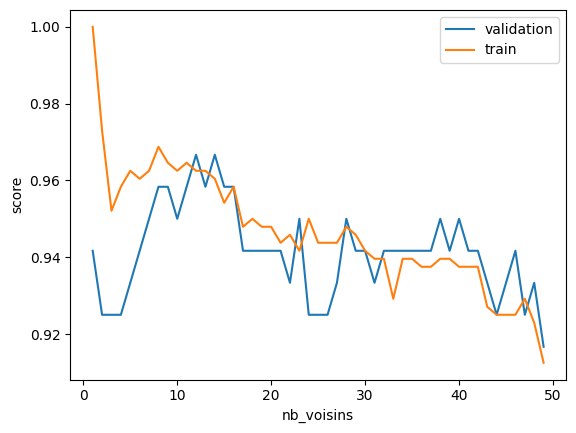

In [24]:
plt.plot(nb_voisins, val_score.mean(axis=1), label='validation')
plt.plot(nb_voisins, train_score.mean(axis=1), label='train')

plt.xlabel('nb_voisins')
plt.ylabel('score')

plt.legend()
plt.show()

# Donc on voit que l'optimal se situe vers un nombre de voisins = 10
# Mais il existe un autre moyen de le savoir bien : Grid Search

## 📍 Grid Search CV

Cependant pour pouvoir tester les combinaisons de plusieurs hyperparamètre on utilise `Grid Search CV`

In [25]:
# Paramètres de du modèle KNeighborsClassifier()
param_grid = {
    'n_neighbors' : np.arange(1, 50),
    'metric' : ['euclidiean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

/Users/ranjith/CODES/VENV/DATA-SCIENCE/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
245 fits failed out of a total of 490.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
245 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/ranjith/CODES/VENV/DATA-SCIENCE/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ranjith/CODES/VENV/DATA-SCIENCE/lib/python3.13/site-packages/sklearn/base.py", line 1356, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/ranjith/CO

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidiean', 'manhattan'], 'n_neighbors': array([ 1, 2..., 47, 48, 49])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(15)


In [26]:
# Meilleures performances
print(grid.best_score_)
print(grid.best_params_)

0.9583333333333334
{'metric': 'manhattan', 'n_neighbors': np.int64(15)}


In [27]:
# On prédit donc avec le modèle qui a les meilleurs performances
modele = grid.best_estimator_
modele.score(X_test, y_test)

1.0

## 📍 Matrice de confusion

In [28]:
y_pred = modele.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]])

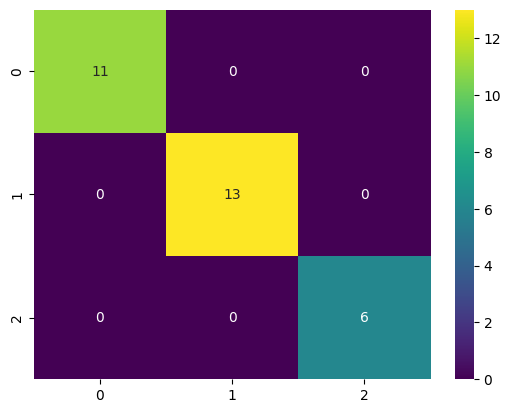

In [30]:
from seaborn import heatmap
heatmap(confusion_matrix(y_test, y_pred), cmap='viridis', annot=True)
plt.show()

## 📍 Learning curve

[ 9 19 28 38 48 57 67 76 86 96]


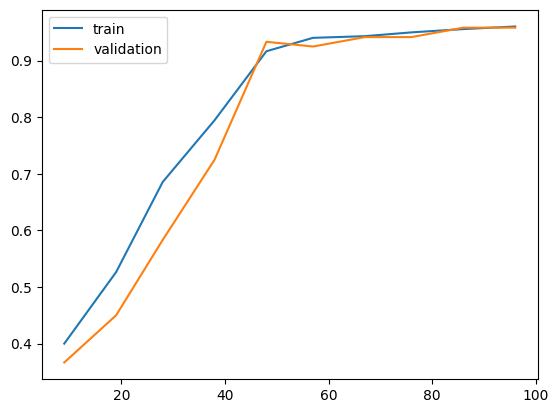

In [ ]:
# On voit qu'a partir de 55% les performaneces commencent à stagner
# De ce fait, il est inutiles de récolter de nouvelles données car cela représente des coûts.

N, train_score, val_score = learning_curve(
    modele, X_train, y_train,
    train_sizes=np.linspace(0.1, 1, 10), # On découpe en de 10% à 100% en 10 lot : donc tous les 10%
    cv=5
)

# Au début on a 9 points, puis 19, puis 28...
# Docnc 50% correspond vers 57 points
# 57 points suffisent pour avoir de bonnes performances pour notre modèle
print(N)

plt.plot(N, train_score.mean(axis=1), label='train')
plt.plot(N, val_score.mean(axis=1), label='validation')

plt.legend()
plt.show()